In [6]:
import sys
sys.path.append('../..')

from muno.utils.data_utils import Heatmap
import numpy as np
import matplotlib.pyplot as plt
import h5py

from typing import Tuple

import torch

In [38]:
def loadShearFlowData(filename: str, dtype) -> Tuple[int, torch.Tensor]:
    with h5py.File(filename, 'r') as h5_file:
        
        v = torch.from_numpy(h5_file['t1_fields']['velocity'][...]).permute(0, 4, 1, 2, 3)
        p = torch.from_numpy(h5_file['t0_fields']['pressure'][...]).unsqueeze(1)

        print(p.shape, v.shape)

In [50]:
filename = '/media/mikemaslyaev/Data/the_well/shear_flow/shear_flow_Reynolds_1e4_Schmidt_1e0.hdf5'

# loadShearFlowData(filename, None)
with h5py.File(filename, 'r') as f:
    print(f.keys())
#     print(f['boundary_conditions']['y_periodic']['mask'][...].shape)
    print(f['dimensions'].keys())
    print(f['dimensions']['time'][0], f['dimensions']['time'][-1], f['dimensions']['time'].size)
    print(f['scalars']['Reynolds'][...]) # 'Schmidt'])
    print(f['t0_fields'].keys(), f['t1_fields']['velocity'].shape)
#     print(Heatmap(f['t0_fields']['pressure'][0, 160, :, :]))#)['velocity'][0, 160, :, :, 0]))
#     print(Heatmap(f['t1_fields']['velocity'][0, 160, :, :, 0]))

<KeysViewHDF5 ['boundary_conditions', 'dimensions', 'scalars', 't0_fields', 't1_fields', 't2_fields']>
<KeysViewHDF5 ['time', 'x', 'y']>
0.0 19.9 200
10000.0
<KeysViewHDF5 ['pressure', 'tracer']> (32, 200, 256, 512, 2)


In [41]:
type(torch.float32)

torch.dtype

In [1]:
import torch
import dill

In [2]:
adapter = torch.load(f='/media/mikemaslyaev/Data/experimental_results/pdebench_multiphysics_20260727_080112/checkpoints/lift_1.pt', pickle_module=dill)

In [3]:
adapter

PostLiftMambaLifting(
  (positional_embedding): GridEmbeddingND()
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 60, kernel_size=(1,), stride=(1,))
      (1): Conv1d(60, 60, kernel_size=(1,), stride=(1,))
    )
  )
  (post_lift_ssm): PostLiftMambaProcessorND(
    (ssm): SimpleSSM(
      (dw): Conv1d(60, 60, kernel_size=(9,), stride=(1,), padding=(4,), groups=60)
      (gate): Conv1d(60, 60, kernel_size=(1,), stride=(1,))
      (norm): LayerNorm((60,), eps=1e-05, elementwise_affine=True)
    )
    (norm): LayerNorm((60,), eps=1e-05, elementwise_affine=True)
  )
)

In [4]:
import transformers
print(transformers.__version__)

5.5.0


In [5]:
import mamba_ssm

In [6]:
mamba_ssm.__version__

'2.2.6.post3'

In [1]:
import torch.nn as nn
import torch


model = torch.nn.Linear(5, 3)
parallelized_model = nn.DataParallel(model)

In [4]:
parallelized_model.module

Linear(in_features=5, out_features=3, bias=True)

dataset keys: <KeysViewHDF5 ['aoa', 're', 't', 'u', 'v', 'x', 'y']>, angle of attack: 0


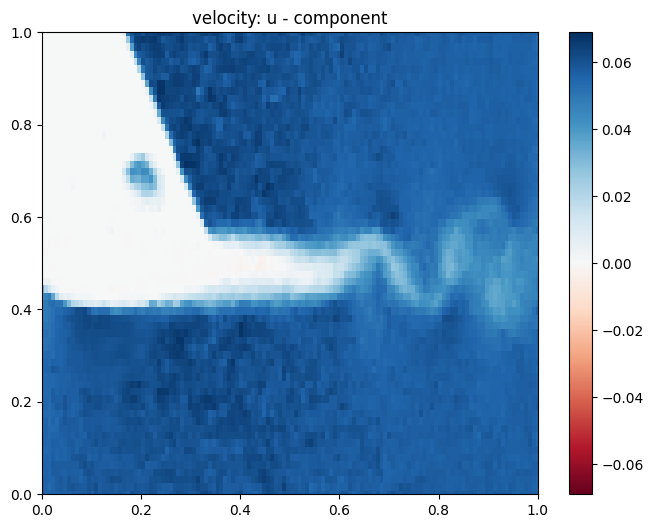

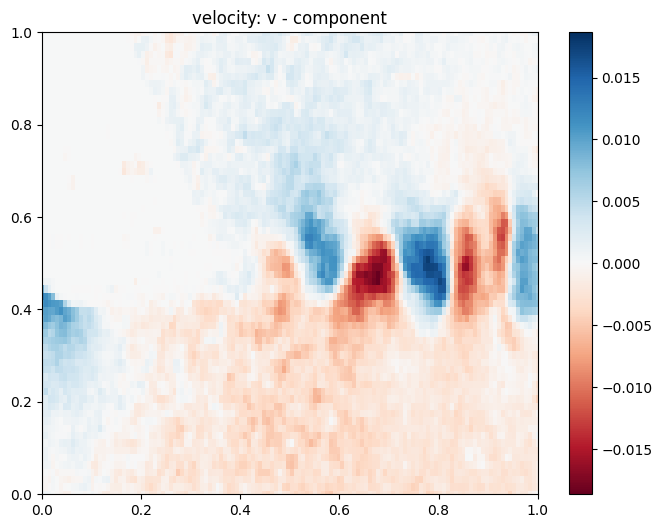

In [ ]:
filename = '/home/mikemaslyaev/Downloads/3750_0(1).h5'

# loadShearFlowData(filename, None)
with h5py.File(filename, 'r') as f:
    print(f"dataset keys: {f.keys()}, angle of attack: {f['aoa'][...]}")
    # Heatmap(np.sqrt(np.power(f['u'][10, ...], 2) + np.power(f['v'][10, ...], 2)))
    Heatmap(f['u'][0, ...], title = 'velocity: u - component')
    Heatmap(f['v'][0, ...], title = 'velocity: v - component')

In [1]:
devices = [1, 2, 4]
print(",".join(map(str, devices)))

1,2,4


In [2]:
a = {1: '1', 2: '2'}
b = {2: 1, 1: 2}

print(a.keys() == b.keys())

True
